# Exploratory Data Analysis (EDA) of 5 Indian Large-Cap Stocks

### Week 5 Mini Project

**Author:** Mohit Singh

**Internship:** Ollosoft Data Science Internship

**Week:** 5

**Objective**

Perform Exploratory Data Analysis on five Indian large-cap stocks using historical market data.

The analysis includes

- Data Summary
- Missing Value Analysis
- Return Distribution
- Correlation Analysis
- Technical Indicators
- Key Insights

## 1. Import Libraries

Import all required Python libraries.

In [81]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

## 2. Download Historical Stock Data

The following five Indian large-cap stocks are downloaded from Yahoo Finance.

In [82]:
tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

close = data["Close"]

close.head()

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-01,595.677246,519.137878,619.740356,672.216187,1841.149658
2020-01-02,599.474121,522.861572,617.932068,683.660217,1832.697754
2020-01-03,590.925293,521.169006,627.436035,684.484009,1869.222412
2020-01-06,578.136658,508.450500,621.422546,668.609314,1869.052246
2020-01-07,587.291260,505.742432,612.212891,678.895630,1873.639404


In [83]:
import yfinance as yf
import pandas as pd

tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

[*********************100%***********************]  5 of 5 completed


## 3. Data Summary

Understand the size, shape and descriptive statistics of the dataset.

In [84]:
close.info()

close.describe()

close.shape

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1238 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HDFCBANK.NS   1238 non-null   float64
 1   ICICIBANK.NS  1238 non-null   float64
 2   INFY.NS       1238 non-null   float64
 3   RELIANCE.NS   1238 non-null   float64
 4   TCS.NS        1238 non-null   float64
dtypes: float64(5)
memory usage: 58.0 KB


(1238, 5)

## 4. Missing Value Analysis

Check whether the dataset contains missing observations.

In [85]:
missing = close.isna().sum()

missing

Ticker
HDFCBANK.NS     0
ICICIBANK.NS    0
INFY.NS         0
RELIANCE.NS     0
TCS.NS          0
dtype: int64

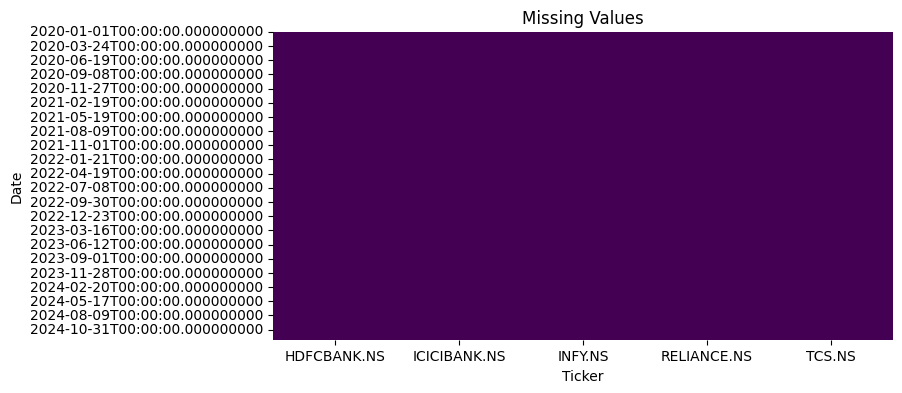

In [86]:
plt.figure(figsize=(8,4))

sns.heatmap(
    close.isna(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")

plt.savefig(
    "../week05/images/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Daily Returns

Daily percentage returns are computed for all five stocks.

In [87]:
returns = close.pct_change(fill_method=None).dropna()

returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-02,0.006374,0.007173,-0.002918,0.017024,-0.004591
2020-01-03,-0.014261,-0.003237,0.015380,0.001205,0.019929
2020-01-06,-0.021642,-0.024404,-0.009584,-0.023192,-0.000091
2020-01-07,0.015835,-0.005326,-0.014820,0.015385,0.002454
2020-01-08,-0.002618,0.005833,-0.013326,-0.007510,0.022395


## 6. Return Distribution

The histogram below shows how daily returns are distributed.

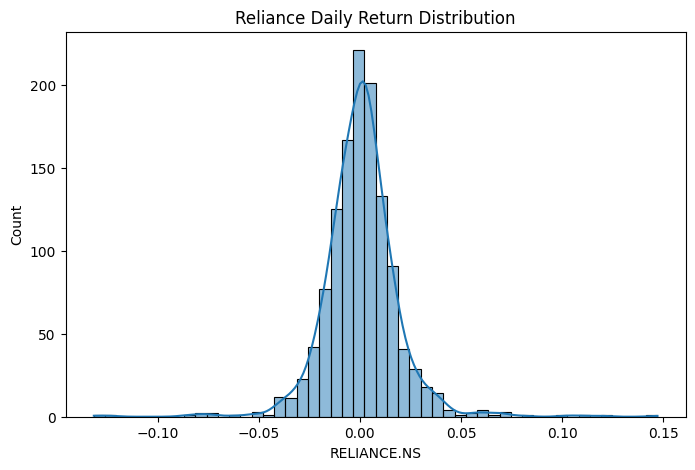

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(
    returns["RELIANCE.NS"],
    bins=50,
    kde=True
)

plt.title("Reliance Daily Return Distribution")

plt.savefig(
    "../week05/images/returns_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Correlation Analysis

Correlation helps identify how similarly stocks move.

In [89]:
corr = returns.corr()

corr

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.639451,0.357704,0.441789,0.313980
ICICIBANK.NS,0.639451,1.000000,0.377474,0.438453,0.335536
INFY.NS,0.357704,0.377474,1.000000,0.361079,0.707904
RELIANCE.NS,0.441789,0.438453,0.361079,1.000000,0.386558
TCS.NS,0.313980,0.335536,0.707904,0.386558,1.000000


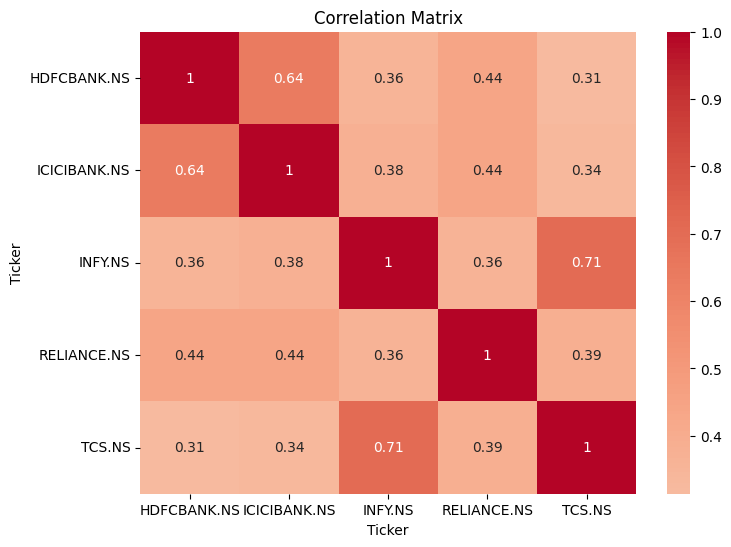

In [90]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Technical Indicators

Moving averages, RSI, MACD and Bollinger Bands were added.

In [91]:
# Extract only Reliance data from the downloaded dataset
reliance = pd.DataFrame({
    "Open": data["Open"]["RELIANCE.NS"],
    "High": data["High"]["RELIANCE.NS"],
    "Low": data["Low"]["RELIANCE.NS"],
    "Close": data["Close"]["RELIANCE.NS"],
    "Volume": data["Volume"]["RELIANCE.NS"]
})

reliance.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-01,675.956671,680.008852,670.390532,672.216187,14004468
2020-01-02,673.284861,686.176147,673.284861,683.660217,17710316
2020-01-03,682.636001,686.487835,678.183067,684.484009,20984698
2020-01-06,676.847260,680.365044,667.050769,668.609314,24519177
2020-01-07,676.401934,683.304036,673.952826,678.895630,16683622


In [92]:
reliance.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2024-12-24,1211.834663,1222.988340,1210.545745,1212.280762,6734917
2024-12-26,1213.767935,1217.188348,1203.853555,1206.133911,10016178
2024-12-27,1207.869004,1217.386785,1206.580087,1210.595459,7000397
2024-12-30,1205.985254,1212.726960,1197.756270,1200.333984,8818766
2024-12-31,1197.657049,1208.661986,1195.822913,1205.043213,6405475


### Bollinger Bands

In [93]:
print(reliance.columns.tolist())

['Open', 'High', 'Low', 'Close', 'Volume']


In [94]:
# ===========================
# Bollinger Bands
# ===========================

# 20-day Simple Moving Average
reliance["SMA20"] = reliance["Close"].rolling(window=20).mean()

# 20-day Rolling Standard Deviation
rolling_std = reliance["Close"].rolling(window=20).std()

# Upper Bollinger Band
reliance["Upper_Band"] = reliance["SMA20"] + (2 * rolling_std)

# Lower Bollinger Band
reliance["Lower_Band"] = reliance["SMA20"] - (2 * rolling_std)

# Verify columns
print(reliance.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'SMA20', 'Upper_Band',
       'Lower_Band'],
      dtype='object')


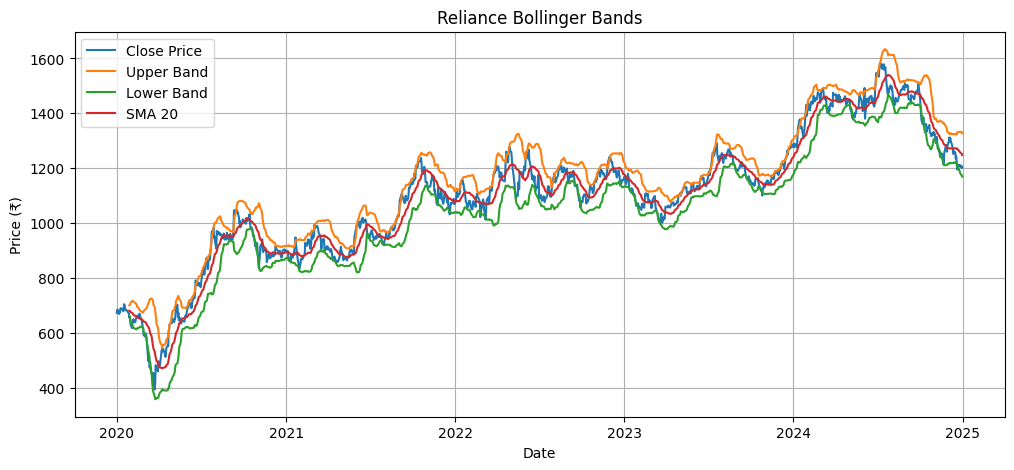

In [95]:
# plt.figure(figsize=(12,5))

# plt.plot(reliance.index, reliance["Close"])

# plt.plot(reliance.index, reliance["Upper_Band"])

# plt.plot(reliance.index, reliance["Lower_Band"])

# plt.legend()

# plt.savefig(
#     "../week05/images/bollinger_bands.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

plt.figure(figsize=(12,5))

# Closing Price
plt.plot(
    reliance.index,
    reliance["Close"],
    label="Close Price"
)

# Upper Band
plt.plot(
    reliance.index,
    reliance["Upper_Band"],
    label="Upper Band"
)

# Lower Band
plt.plot(
    reliance.index,
    reliance["Lower_Band"],
    label="Lower Band"
)

# Moving Average
plt.plot(
    reliance.index,
    reliance["SMA20"],
    label="SMA 20"
)

plt.title("Reliance Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../week05/images/bollinger_bands.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Rolling Correlation

Rolling correlation between Reliance and Nifty 50 shows how their relationship changes over time.

In [96]:
close.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-01,595.677246,519.137878,619.740356,672.216187,1841.149658
2020-01-02,599.474121,522.861572,617.932068,683.660217,1832.697754
2020-01-03,590.925293,521.169006,627.436035,684.484009,1869.222412
2020-01-06,578.136658,508.450500,621.422546,668.609314,1869.052246
2020-01-07,587.291260,505.742432,612.212891,678.895630,1873.639404


In [97]:
returns = close.pct_change(fill_method=None).dropna()

In [98]:
rolling_corr = (
    returns["RELIANCE.NS"]
    .rolling(window=60)
    .corr(returns["TCS.NS"])
)



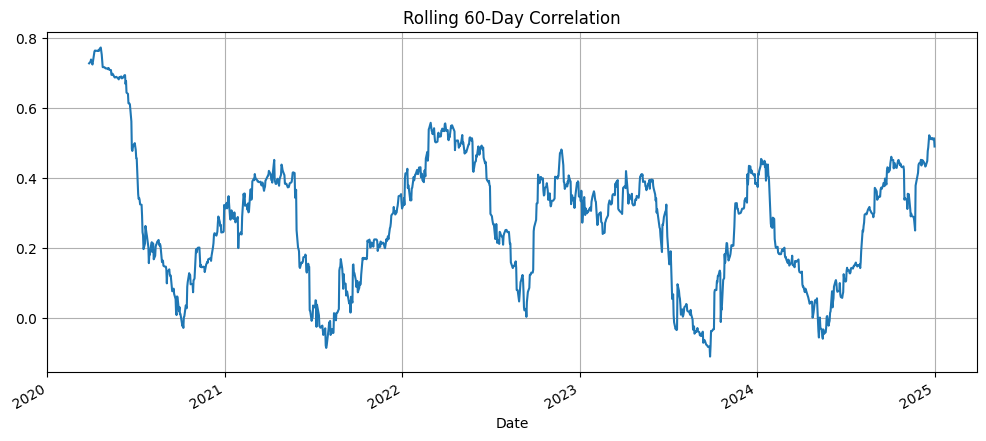

In [99]:
rolling_corr.plot(figsize=(12,5))

plt.title("Rolling 60-Day Correlation")

plt.grid()

plt.savefig(
    "../week05/images/rolling_correlation01.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10. Key Observations

### Data Quality

The downloaded data contained very few missing values and was suitable for analysis.


### Return Distribution

Daily returns are centered around zero with occasional large positive and negative movements.


### Correlation

INFY and TCS showed the strongest positive correlation, while banking stocks exhibited moderate correlations with IT stocks.


### Technical Indicators

Moving averages captured the long-term trend, while RSI identified periods of overbought and oversold conditions. Bollinger Bands highlighted phases of increased market volatility.


### Rolling Correlation

The relationship between Reliance and the Nifty 50 remained generally strong, with temporary declines during periods of higher market uncertainty.

# Conclusion

This exploratory data analysis demonstrated how multiple statistical and visualization techniques can be combined to better understand stock market behavior.

Key findings include:

- High correlation among stocks from similar sectors.
- Daily returns approximately centered around zero.
- Technical indicators effectively highlighted market trends and momentum.
- Rolling correlation revealed changing relationships between Reliance and the Nifty 50 over time.

Overall, the analysis provides a solid foundation for future predictive modeling and portfolio analysis.